## NEP_Force_error

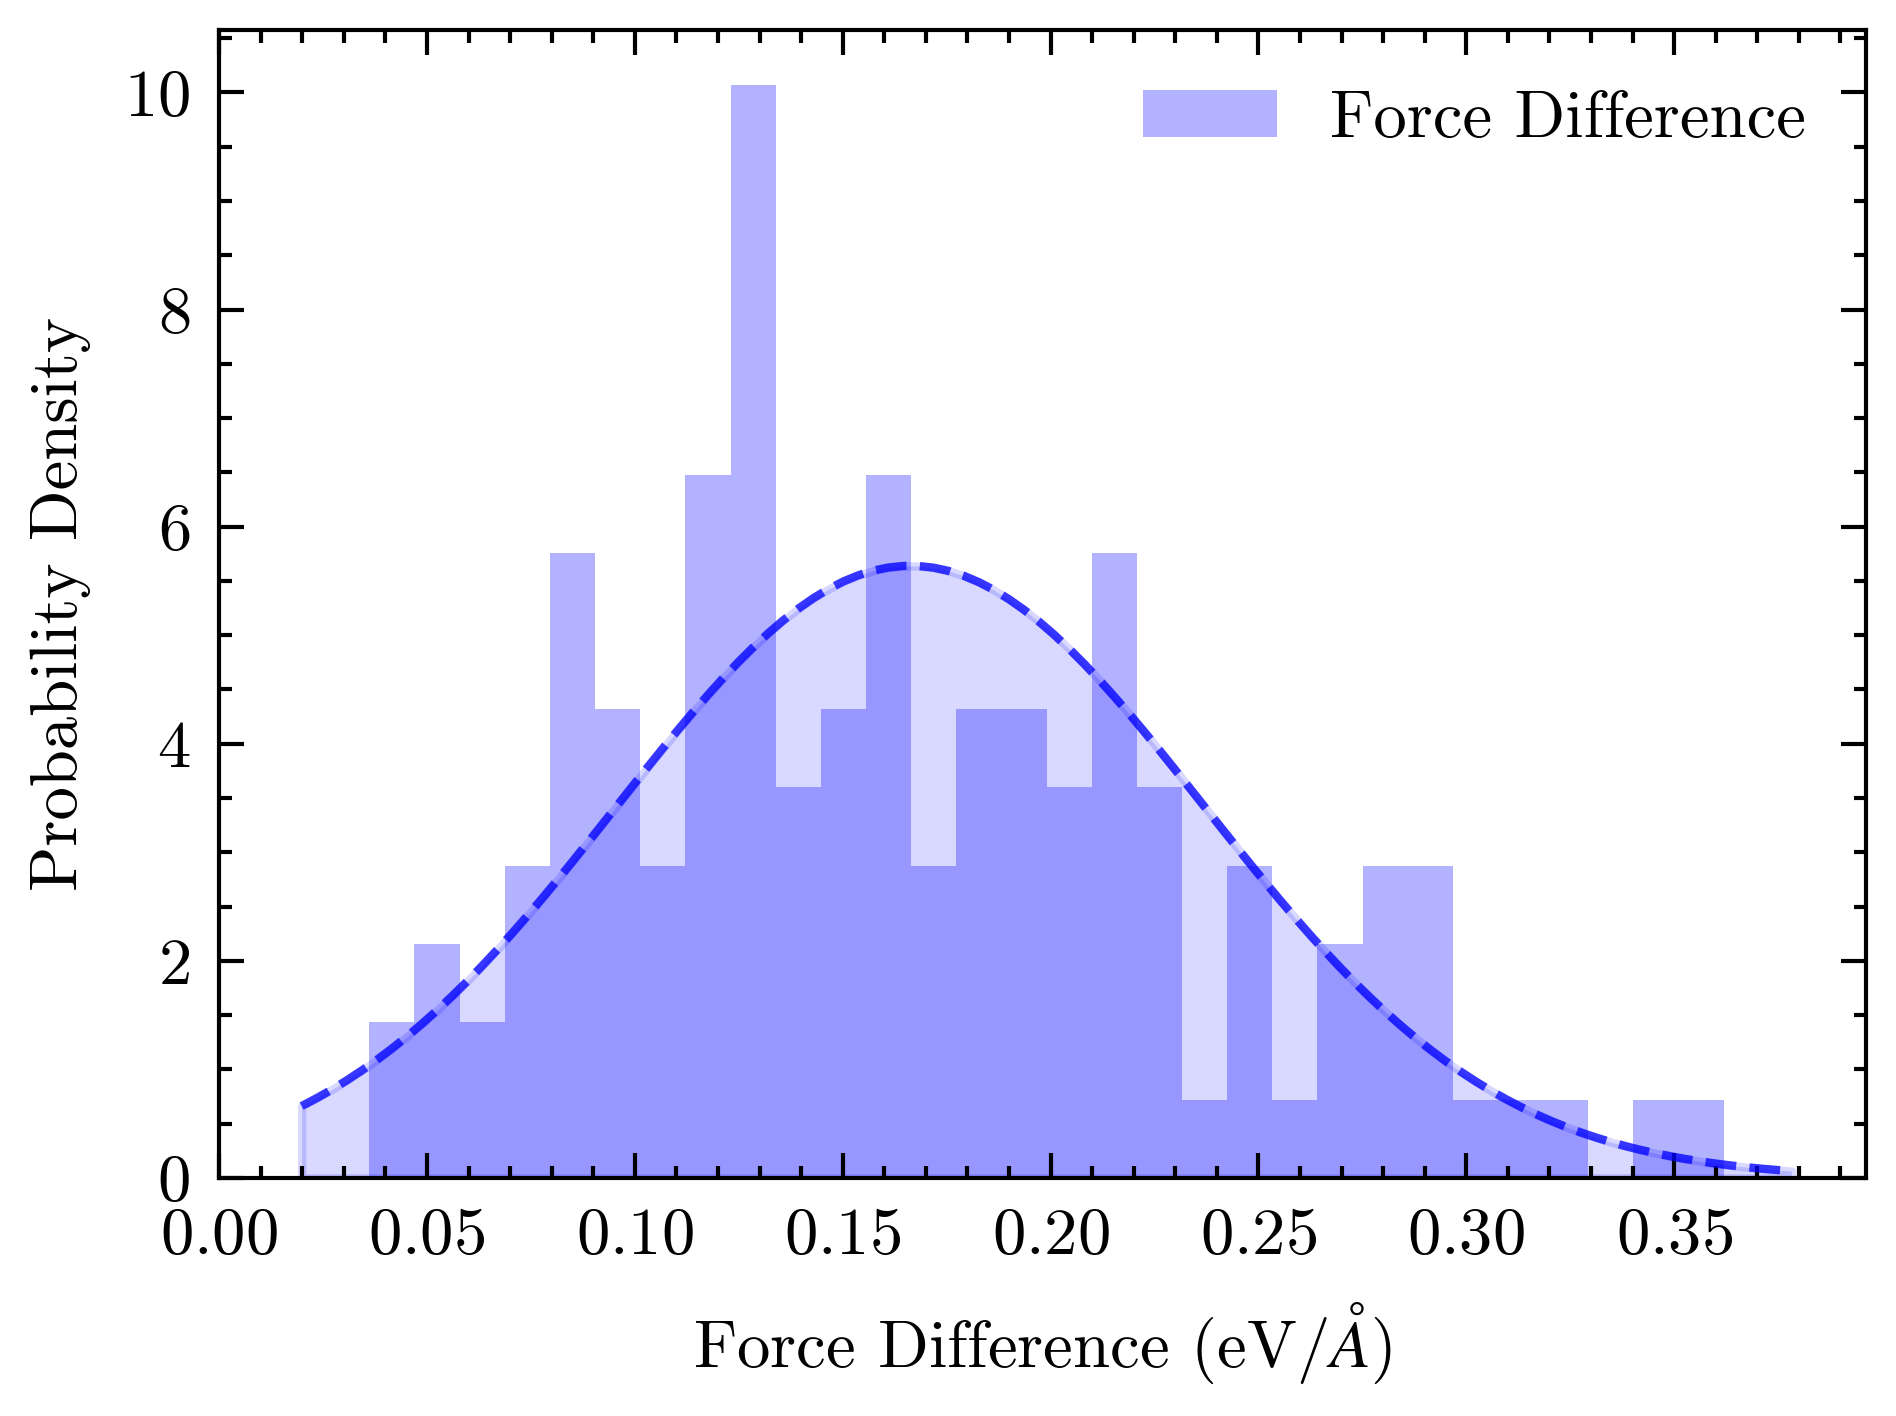

In [1]:
'''
文件名：force_comparison.py
运行方法：python force_comparison.py
功能描述：比较XYZ文件中多个构型的原子受力与NEP计算得到的原子受力，并绘制差值的分布图。
输入文件：../dataset/perfect.xyz nep.txt
'''

import matplotlib.pyplot as plt
import numpy as np
import os
import scienceplots
import sys
from ase.calculators.mixing import SumCalculator
from ase.io import read, iread
from calorine.calculators import CPUNEP
from dftd3.ase import DFTD3
from scipy.stats import norm

plt.style.use(['science','ieee','no-latex','bright'])

def nep_calculator(filename="../nep.txt", use_dftd3=False):
    """
    配置NEP计算器，若需色散校正，则use_dftd3=True
    """
    if os.path.exists(filename):
        if use_dftd3:
            return SumCalculator([CPUNEP(filename), DFTD3(method="pbe", damping="d3bj")])
        return CPUNEP(filename)
    print(f"File {filename} does not exist.")
    sys.exit(1)

def plot_force_difference(force_diffs, color, label):
    plt.hist(force_diffs, bins=30, color=color, alpha=0.3, density=True, label=label)
    xmin, xmax = plt.xlim()
    x_values = np.linspace(xmin, xmax, 100)
    mean_diff, std_diff = norm.fit(force_diffs)
    pdf_diff = norm.pdf(x_values, mean_diff, std_diff)
    plt.plot(x_values, pdf_diff, linewidth=1, linestyle='--', color=color, alpha=0.75)
    plt.fill_between(x_values, pdf_diff, where=(pdf_diff >= 0), color=color, alpha=0.15)

def compare_forces(xyz_filepath):
    all_force_diffs = []
    for structure in iread(xyz_filepath):
        forces_xyz = structure.get_forces()
        structure.calc = nep_calculator()
        forces_nep = structure.get_forces()
        force_diff = forces_xyz - forces_nep
        norm_force_diff = np.linalg.norm(force_diff, axis=1)
        all_force_diffs.extend(norm_force_diff)
    all_force_diffs = np.array(all_force_diffs)
    plot_force_difference(all_force_diffs, 'blue', 'Force Difference')
    plt.xlabel('Force Difference (eV/$Å$)')
    plt.ylabel('Probability Density')
    plt.xlim(0, None)
    plt.legend()
    plt.tight_layout()
    plt.savefig('force_difference.png', bbox_inches='tight')

if __name__ == "__main__":
    xyz_filepath = "./reference.xyz"
    compare_forces(xyz_filepath)


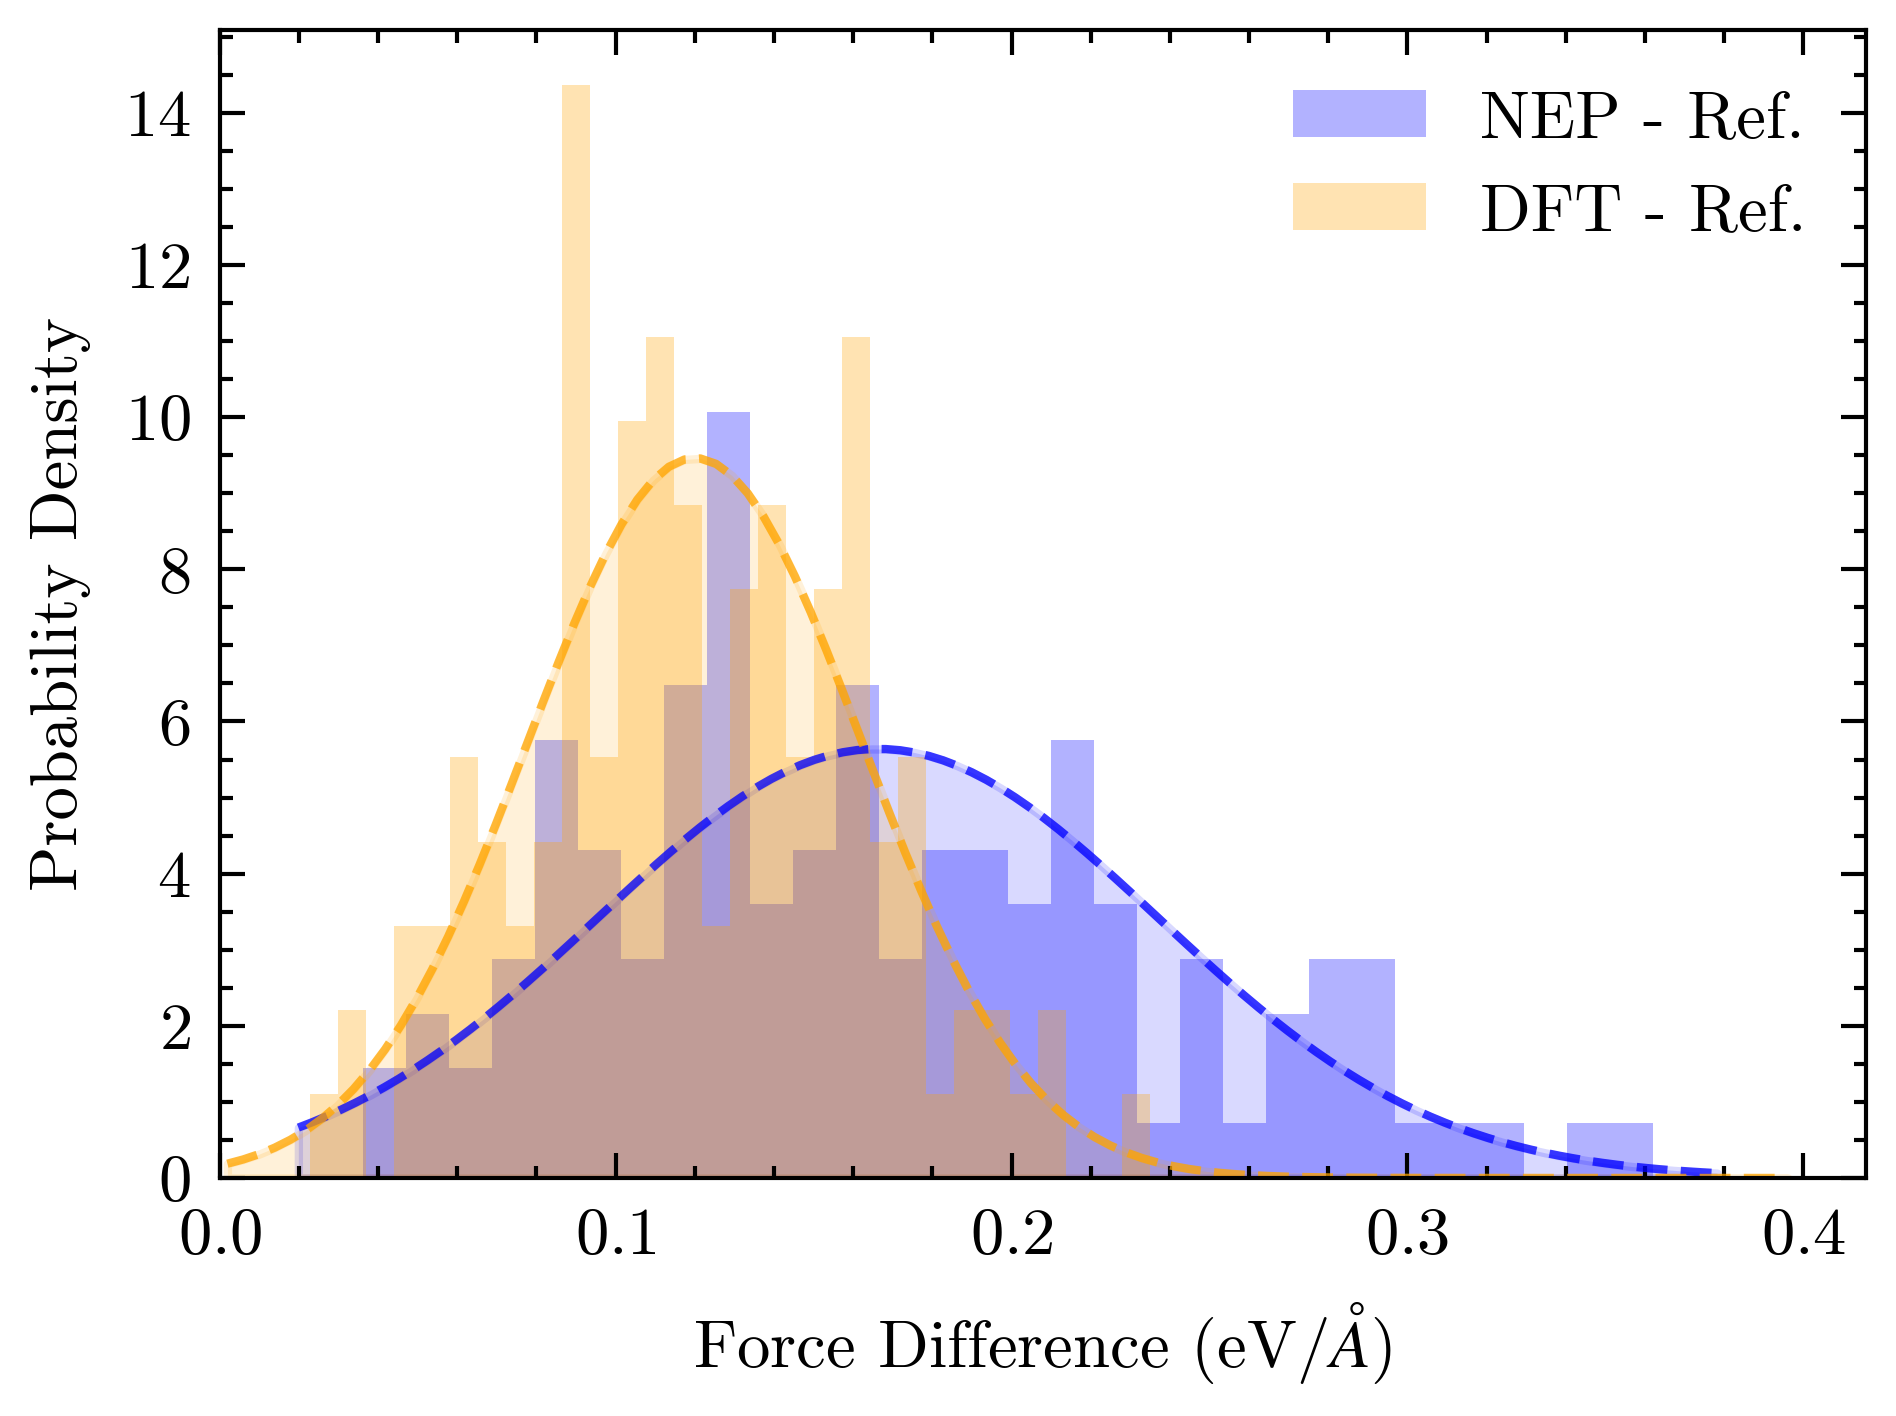

In [2]:
structure_ref = read("./reference.xyz")
forces_ref = structure_ref.get_forces()

structure_1 = read("./test_1.xyz")
forces_1 = structure_1.get_forces()

structure = read("./reference.xyz")
structure.calc = nep_calculator()
forces_nep = structure.get_forces()

diff_nep = forces_ref - forces_nep
norm_nep = np.linalg.norm(diff_nep, axis=1)
diff_1 = forces_ref - forces_1
norm_1 = np.linalg.norm(diff_1, axis=1)

plot_force_difference(norm_nep, 'blue', 'NEP - Ref.')
plot_force_difference(norm_1, 'orange', 'DFT - Ref.')

plt.xlabel('Force Difference (eV/$Å$)')
plt.ylabel('Probability Density')
plt.xlim(0, None)
plt.legend()
plt.tight_layout()
plt.savefig('force_difference_vs_dft.png', bbox_inches='tight')